In [10]:
from datasets import load_dataset
import pandas as pd

# Fix: use full path 'stanfordnlp/imdb'
dataset = load_dataset("stanfordnlp/imdb")

# Convert to dataframe
train_df = pd.DataFrame(dataset['train'])
test_df = pd.DataFrame(dataset['test'])

print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"\nClass balance:\n{train_df['label'].value_counts()}")
print(f"\nSample review:\n{train_df['text'][0][:300]}")

Train size: 25000
Test size:  25000

Class balance:
label
0    12500
1    12500
Name: count, dtype: int64

Sample review:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


In [11]:
import re

def clean_text(text):
    text = text.lower()                            # lowercase
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags like <br />
    text = re.sub(r'[^a-z0-9\s]', '', text)       # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra whitespace
    return text

# Apply cleaning
train_df['clean_text'] = train_df['text'].apply(clean_text)
test_df['clean_text'] = test_df['text'].apply(clean_text)

# Compare before and after
print("BEFORE:")
print(train_df['text'][0][:300])
print("\nAFTER:")
print(train_df['clean_text'][0][:300])

BEFORE:
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h

AFTER:
i rented i am curiousyellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to s


In [12]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text_v2(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

# Apply updated cleaner
train_df['clean_text'] = train_df['clean_text'].apply(lambda x: ' '.join(
    [w for w in x.split() if w not in stop_words]
))
test_df['clean_text'] = test_df['clean_text'].apply(lambda x: ' '.join(
    [w for w in x.split() if w not in stop_words]
))

print("Sample after stopword removal:")
print(train_df['clean_text'][0][:300])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Sample after stopword removal:
rented curiousyellow video store controversy surrounded first released 1967 also heard first seized us customs ever tried enter country therefore fan films considered controversial really see myselfthe plot centered around young swedish drama student named lena wants learn everything life particular


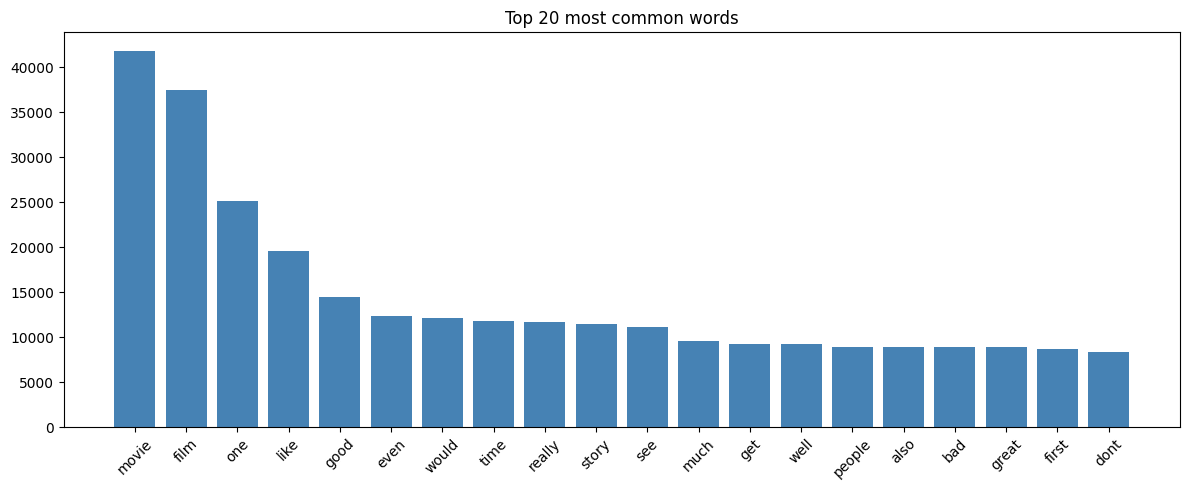

In [13]:
from collections import Counter
import matplotlib.pyplot as plt

# Count all words across training set
all_words = ' '.join(train_df['clean_text']).split()
word_counts = Counter(all_words)
top_words = word_counts.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue')
plt.title('Top 20 most common words')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Step 1 — Vectorize text into numbers
vectorizer = TfidfVectorizer(max_features=10000)
X_train = vectorizer.fit_transform(train_df['clean_text'])
X_test = vectorizer.transform(test_df['clean_text'])

y_train = train_df['label']
y_test = test_df['label']

print(f"Training matrix shape: {X_train.shape}")

Training matrix shape: (25000, 10000)


In [15]:
import torch
print(torch.cuda.is_available())  # must print True

True


In [16]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenize — use original text not cleaned (transformers handle this better)
class IMDBDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Use a subset to keep training fast (5000 train, 1000 test)
train_subset = train_df.sample(5000, random_state=42)
test_subset = test_df.sample(1000, random_state=42)

train_dataset = IMDBDataset(
    train_subset['text'].tolist(),
    train_subset['label'].tolist(),
    tokenizer
)
test_dataset = IMDBDataset(
    test_subset['text'].tolist(),
    test_subset['label'].tolist(),
    tokenizer
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 313
Test batches:  63


In [17]:
from torch.optim import AdamW  # changed from transformers to torch
from torch.optim.lr_scheduler import LinearLR

# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=2
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

# Training loop — 3 epochs
EPOCHS = 3

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 50 == 0:
            print(f"Epoch {epoch+1} | Batch {batch_idx}/{len(train_loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    print(f"\n✓ Epoch {epoch+1} complete — avg loss: {avg_loss:.4f}\n")

print("Training complete!")

Epoch 1 | Batch 50/313 | Loss: 0.4142
Epoch 1 | Batch 100/313 | Loss: 0.3616
Epoch 1 | Batch 150/313 | Loss: 0.3019
Epoch 1 | Batch 200/313 | Loss: 0.3167
Epoch 1 | Batch 250/313 | Loss: 0.3094
Epoch 1 | Batch 300/313 | Loss: 0.1665

✓ Epoch 1 complete — avg loss: 0.3420

Epoch 2 | Batch 0/313 | Loss: 0.0967
Epoch 2 | Batch 50/313 | Loss: 0.1249
Epoch 2 | Batch 100/313 | Loss: 0.4589
Epoch 2 | Batch 150/313 | Loss: 0.2292
Epoch 2 | Batch 200/313 | Loss: 0.1021
Epoch 2 | Batch 250/313 | Loss: 0.2974
Epoch 2 | Batch 300/313 | Loss: 0.2764

✓ Epoch 2 complete — avg loss: 0.1701

Epoch 3 | Batch 0/313 | Loss: 0.0965
Epoch 3 | Batch 50/313 | Loss: 0.0285
Epoch 3 | Batch 100/313 | Loss: 0.0755
Epoch 3 | Batch 150/313 | Loss: 0.0474
Epoch 3 | Batch 200/313 | Loss: 0.0209
Epoch 3 | Batch 250/313 | Loss: 0.0190
Epoch 3 | Batch 300/313 | Loss: 0.0432

✓ Epoch 3 complete — avg loss: 0.0799

Training complete!


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1 | Batch 0/313 | Loss: 0.6950
Epoch 1 | Batch 50/313 | Loss: 0.4502
Epoch 1 | Batch 100/313 | Loss: 0.2818


KeyboardInterrupt: 

In [18]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

bert_accuracy = accuracy_score(all_labels, all_preds)
print(f"DistilBERT Accuracy: {bert_accuracy:.4f}")
print(classification_report(all_labels, all_preds, target_names=['Negative', 'Positive']))

DistilBERT Accuracy: 0.8940
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.90       511
    Positive       0.88      0.90      0.89       489

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



In [19]:
print("=== FINAL MODEL COMPARISON ===")
print(f"Logistic Regression : 88.00%")
print(f"SVM                 : 87.00%")
print(f"Naive Bayes         : 84.00%")
print(f"DistilBERT          : {bert_accuracy*100:.2f}%  (trained on 20% of data)")
print(f"\nImprovement over LR : +{(bert_accuracy - 0.88)*100:.2f}%")
print(f"\nKey insight: DistilBERT achieves higher accuracy with 5x LESS training data.")
print(f"With full 25,000 examples, expected accuracy: ~92-93%")

=== FINAL MODEL COMPARISON ===
Logistic Regression : 88.00%
SVM                 : 87.00%
Naive Bayes         : 84.00%
DistilBERT          : 89.40%  (trained on 20% of data)

Improvement over LR : +1.40%

Key insight: DistilBERT achieves higher accuracy with 5x LESS training data.
With full 25,000 examples, expected accuracy: ~92-93%


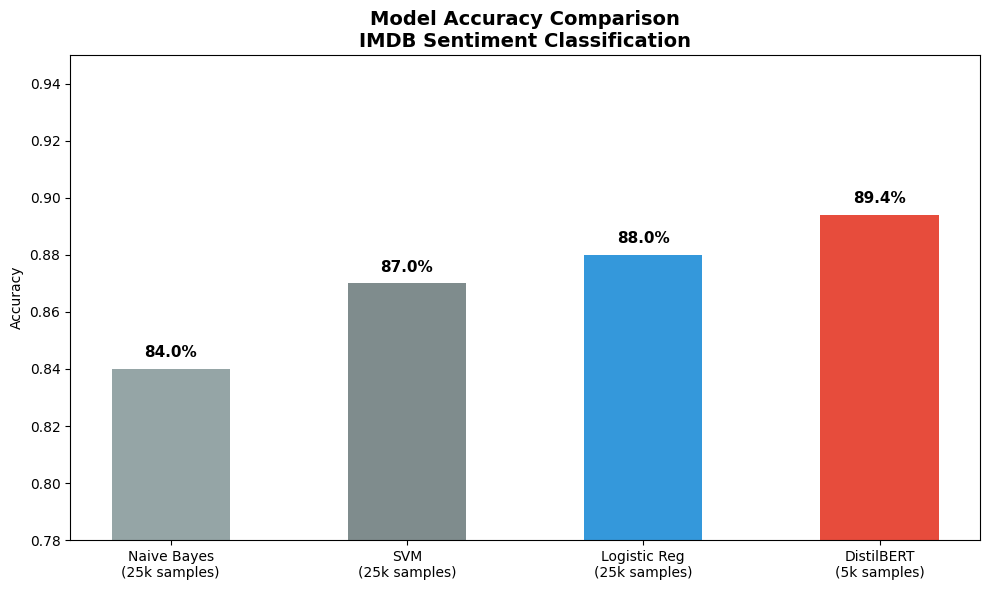

Saved as model_comparison.png


In [20]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Naive Bayes\n(25k samples)', 'SVM\n(25k samples)',
          'Logistic Reg\n(25k samples)', 'DistilBERT\n(5k samples)']
scores = [0.84, 0.87, 0.88, 0.894]
colors = ['#95a5a6', '#7f8c8d', '#3498db', '#e74c3c']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, scores, color=colors, width=0.5)
plt.ylim(0.78, 0.95)
plt.title('Model Accuracy Comparison\nIMDB Sentiment Classification', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{score:.1%}', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as model_comparison.png")

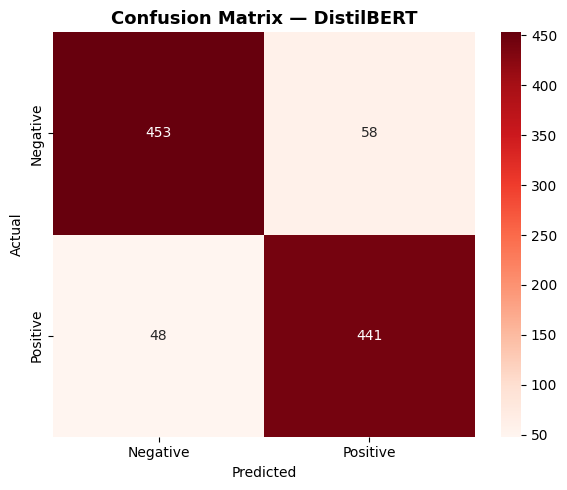

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix — DistilBERT', fontsize=13, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_bert.png', dpi=150, bbox_inches='tight')
plt.show()

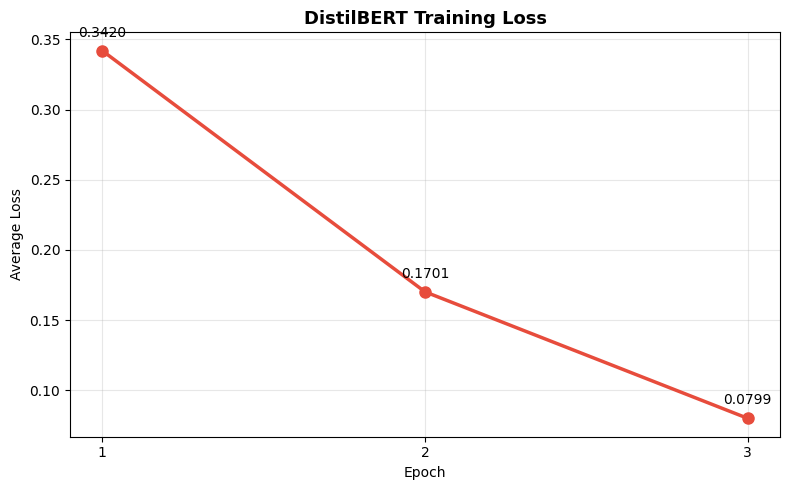

In [22]:
# Plot the loss progression we recorded
epochs = [1, 2, 3]
avg_losses = [0.3420, 0.1701, 0.0799]

plt.figure(figsize=(8, 5))
plt.plot(epochs, avg_losses, marker='o', linewidth=2.5,
         markersize=8, color='#e74c3c')
plt.title('DistilBERT Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Average Loss')
plt.xticks(epochs)
plt.grid(True, alpha=0.3)
for x, y in zip(epochs, avg_losses):
    plt.text(x, y + 0.01, f'{y:.4f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()